In [1]:
from Bio.Seq import Seq
from Bio import SeqIO
import json
from datetime import datetime

In [2]:
clusters_file='/media/ktht/ExtraUbuntu/amromics/panta2/panta/out/test/g_mmseq_a_diamond_c_mcl_unique3_all/annotated_clusters.json'
unque_seq_file='/media/ktht/ExtraUbuntu/amromics/panta2/panta/out/test/g_mmseq_a_diamond_c_mcl_unique3_all/unique_seqs.fasta'


In [3]:
aa=['A','R','N','D','C','Q','E','G','H','I','L','K','M','S','P','F','T','W','Y','V']
k2aa=[]
for a in aa:
    for b in aa:
        k2aa.append(a+b)
print (len(k2aa))
print (k2aa)
index_kaa={}
for i in range(len(k2aa)):
    index_kaa[k2aa[i]]=i
k3aa=[]
for a in aa:
    for b in aa:
        for c in aa:
            k3aa.append(a+b+c)
print (len(k3aa))
#print (k2aa)
index_k3aa={}
for i in range(len(k3aa)):
    index_k3aa[k3aa[i]]=i
  

400
['AA', 'AR', 'AN', 'AD', 'AC', 'AQ', 'AE', 'AG', 'AH', 'AI', 'AL', 'AK', 'AM', 'AS', 'AP', 'AF', 'AT', 'AW', 'AY', 'AV', 'RA', 'RR', 'RN', 'RD', 'RC', 'RQ', 'RE', 'RG', 'RH', 'RI', 'RL', 'RK', 'RM', 'RS', 'RP', 'RF', 'RT', 'RW', 'RY', 'RV', 'NA', 'NR', 'NN', 'ND', 'NC', 'NQ', 'NE', 'NG', 'NH', 'NI', 'NL', 'NK', 'NM', 'NS', 'NP', 'NF', 'NT', 'NW', 'NY', 'NV', 'DA', 'DR', 'DN', 'DD', 'DC', 'DQ', 'DE', 'DG', 'DH', 'DI', 'DL', 'DK', 'DM', 'DS', 'DP', 'DF', 'DT', 'DW', 'DY', 'DV', 'CA', 'CR', 'CN', 'CD', 'CC', 'CQ', 'CE', 'CG', 'CH', 'CI', 'CL', 'CK', 'CM', 'CS', 'CP', 'CF', 'CT', 'CW', 'CY', 'CV', 'QA', 'QR', 'QN', 'QD', 'QC', 'QQ', 'QE', 'QG', 'QH', 'QI', 'QL', 'QK', 'QM', 'QS', 'QP', 'QF', 'QT', 'QW', 'QY', 'QV', 'EA', 'ER', 'EN', 'ED', 'EC', 'EQ', 'EE', 'EG', 'EH', 'EI', 'EL', 'EK', 'EM', 'ES', 'EP', 'EF', 'ET', 'EW', 'EY', 'EV', 'GA', 'GR', 'GN', 'GD', 'GC', 'GQ', 'GE', 'GG', 'GH', 'GI', 'GL', 'GK', 'GM', 'GS', 'GP', 'GF', 'GT', 'GW', 'GY', 'GV', 'HA', 'HR', 'HN', 'HD', 'HC', 'HQ',

In [4]:
from collections import Counter
def convertSeq2KmerCount(k,index_kaa,seq):
    kmers = [seq[i:i+k] for i in range(len(seq) - k + 1)]
    kmer_counts = Counter(kmers)
    kc_profile=[0]*len(index_kaa)
    for kmer,count in kmer_counts.items():
        kc_profile[index_kaa[kmer]]=1
    return kc_profile
        

In [5]:
clusters=json.load(open(clusters_file, 'r'))


In [6]:
import numpy as np


def manhattan_distance(v1, v2):
    return np.sum(np.abs(np.array(v1) - np.array(v2)))


def pairwise_manhattan_distance(vectors):
    num_vectors = len(vectors)
    distances = np.zeros((num_vectors, num_vectors))  
    
    for i in range(num_vectors):
        for j in range(i + 1, num_vectors):
            dist = manhattan_distance(vectors[i], vectors[j])
            distances[i, j] = dist
            distances[j, i] = dist  
    
    return distances
def euclidean_distance(v1, v2):
    return round(np.sqrt(np.sum((np.array(v1) - np.array(v2)) ** 2)),2)

# Function to calculate pairwise Euclidean distances for a list of vectors
def pairwise_euclidean_distance(vectors):
    num_vectors = len(vectors)
    distances = np.zeros((num_vectors, num_vectors))  # Initialize a square matrix for distances
    
    for i in range(num_vectors):
        for j in range(i + 1, num_vectors):
            dist = euclidean_distance(vectors[i], vectors[j])
            distances[i, j] = dist
            distances[j, i] = dist  # Since distance is symmetric
    
    return distances
def pairwise_euclidean_distance2(vectors):
    v=np.array(vectors)
    distances =  np.dot(v, v.T)
    
    
    
    return np.sqrt(distances)

In [7]:
list_profile2k=[]
list_profile3k=[]
target_clusters=['acrF','aes','ais']
for target in target_clusters:
    list_seqs=clusters[target]['unique_seq']
    print('number of seqs in '+target+':'+str(len(list_seqs)))
          
    with open(unque_seq_file) as handle:
        for record in SeqIO.parse(handle, "fasta"):
            if record.id in list_seqs:
                list_profile2k.append(convertSeq2KmerCount(2,index_kaa,str(record.seq)))
                list_profile3k.append(convertSeq2KmerCount(3,index_k3aa,str(record.seq)))
print(list_profile2k[0])

number of seqs in acrF:3
number of seqs in aes:4
number of seqs in ais:4
[1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,

In [8]:
import torch
import esm
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()  # disables dropout for deterministic results
data=[]
for target in target_clusters:
    list_seqs=clusters[target]['unique_seq']
    print('number of seqs in '+target+':'+str(len(list_seqs)))
          
    with open(unque_seq_file) as handle:
        for record in SeqIO.parse(handle, "fasta"):
            if record.id in list_seqs:
                data.append((record.id,str(record.seq)))
starttime = datetime.now()
batch_labels, batch_strs, batch_tokens = batch_converter(data)
elapsed = datetime.now() - starttime
print(f'time taken {str(elapsed)}')
list_vec=[]
for i in range(len(batch_tokens)):
    list_vec.append(batch_tokens[i].numpy().tolist())
#print(list_vec)    

number of seqs in acrF:3
number of seqs in aes:4
number of seqs in ais:4
time taken 0:00:00.037916


In [9]:



# Calculate pairwise distances
dist_matrix = pairwise_manhattan_distance(list_vec)

# Print the distance matrix
print("Pairwise Manhattan Distance Matrix:")
print(dist_matrix)
dist_matrix = pairwise_euclidean_distance2(list_vec)

# Print the distance matrix
print("Pairwise Euclidean Distance Matrix:")
print(dist_matrix)

Pairwise Manhattan Distance Matrix:
[[   0. 4068. 4056. 8674. 8685. 8671. 8607. 9157. 9025. 8991. 9155.]
 [4068.    0. 4030. 8706. 8717. 8697. 8665. 9153. 9057. 9031. 9143.]
 [4056. 4030.    0. 8862. 8879. 8859. 8831. 9359. 9233. 9139. 9357.]
 [8674. 8706. 8862.    0.   49.   69.  127. 2531. 2499. 2439. 2527.]
 [8685. 8717. 8879.   49.    0.   88.  146. 2514. 2498. 2442. 2510.]
 [8671. 8697. 8859.   69.   88.    0.  118. 2514. 2488. 2432. 2510.]
 [8607. 8665. 8831.  127.  146.  118.    0. 2552. 2508. 2452. 2548.]
 [9157. 9153. 9359. 2531. 2514. 2514. 2552.    0. 1322. 1374.   20.]
 [9025. 9057. 9233. 2499. 2498. 2488. 2508. 1322.    0. 1418. 1320.]
 [8991. 9031. 9139. 2439. 2442. 2432. 2452. 1374. 1418.    0. 1370.]
 [9155. 9143. 9357. 2527. 2510. 2510. 2548.   20. 1320. 1370.    0.]]
Pairwise Euclidean Distance Matrix:
[[378.57892176 352.75062013 354.67731814 217.11057091 216.38160735
  217.09214633 218.751      182.58696558 186.11286898 189.02380802
  182.91528094]
 [352.75062013 378

In [10]:
# Calculate pairwise distances
dist_matrix = pairwise_manhattan_distance(list_vec)

# Print the distance matrix
print("Pairwise Manhattan Distance Matrix:")
print(dist_matrix)
dist_matrix = pairwise_euclidean_distance(list_vec)

# Print the distance matrix
print("Pairwise Euclidean Distance Matrix:")
print(dist_matrix)

Pairwise Manhattan Distance Matrix:
[[   0. 4068. 4056. 8674. 8685. 8671. 8607. 9157. 9025. 8991. 9155.]
 [4068.    0. 4030. 8706. 8717. 8697. 8665. 9153. 9057. 9031. 9143.]
 [4056. 4030.    0. 8862. 8879. 8859. 8831. 9359. 9233. 9139. 9357.]
 [8674. 8706. 8862.    0.   49.   69.  127. 2531. 2499. 2439. 2527.]
 [8685. 8717. 8879.   49.    0.   88.  146. 2514. 2498. 2442. 2510.]
 [8671. 8697. 8859.   69.   88.    0.  118. 2514. 2488. 2432. 2510.]
 [8607. 8665. 8831.  127.  146.  118.    0. 2552. 2508. 2452. 2548.]
 [9157. 9153. 9359. 2531. 2514. 2514. 2552.    0. 1322. 1374.   20.]
 [9025. 9057. 9233. 2499. 2498. 2488. 2508. 1322.    0. 1418. 1320.]
 [8991. 9031. 9139. 2439. 2442. 2432. 2452. 1374. 1418.    0. 1370.]
 [9155. 9143. 9357. 2527. 2510. 2510. 2548.   20. 1320. 1370.    0.]]
Pairwise Euclidean Distance Matrix:
[[  0.   193.84 196.33 318.6  318.74 318.23 316.68 330.05 327.46 327.42
  330.02]
 [193.84   0.   191.31 317.97 318.11 317.43 316.81 329.09 327.   327.6
  328.89]
 [196

In [11]:
# Calculate pairwise distances
dist_matrix = pairwise_manhattan_distance(list_profile2k)

# Print the distance matrix
print("Pairwise Manhattan Distance Matrix:")
print(dist_matrix)
dist_matrix = pairwise_euclidean_distance(list_profile2k)

# Print the distance matrix
print("Pairwise Euclidean Distance Matrix:")
print(dist_matrix)

Pairwise Manhattan Distance Matrix:
[[  0.  47.  40. 175. 166. 172. 170. 190. 189. 182. 192.]
 [ 47.   0.  53. 160. 157. 161. 159. 197. 192. 187. 195.]
 [ 40.  53.   0. 181. 174. 178. 174. 204. 199. 196. 202.]
 [175. 160. 181.   0.  13.  13.  25. 181. 178. 175. 179.]
 [166. 157. 174.  13.   0.  20.  32. 184. 181. 178. 182.]
 [172. 161. 178.  13.  20.   0.  18. 180. 177. 174. 178.]
 [170. 159. 174.  25.  32.  18.   0. 180. 177. 174. 178.]
 [190. 197. 204. 181. 184. 180. 180.   0.   7.  16.   4.]
 [189. 192. 199. 178. 181. 177. 177.   7.   0.  13.   3.]
 [182. 187. 196. 175. 178. 174. 174.  16.  13.   0.  16.]
 [192. 195. 202. 179. 182. 178. 178.   4.   3.  16.   0.]]
Pairwise Euclidean Distance Matrix:
[[ 0.    6.86  6.32 13.23 12.88 13.11 13.04 13.78 13.75 13.49 13.86]
 [ 6.86  0.    7.28 12.65 12.53 12.69 12.61 14.04 13.86 13.67 13.96]
 [ 6.32  7.28  0.   13.45 13.19 13.34 13.19 14.28 14.11 14.   14.21]
 [13.23 12.65 13.45  0.    3.61  3.61  5.   13.45 13.34 13.23 13.38]
 [12.88 12.53

[[ 0 20  5 ...  1  1  1]
 [ 0 20  5 ...  1  1  1]
 [ 0 20 14 ... 21 21  2]
 ...
 [ 0  4  8 ...  1  1  1]
 [ 0 20  8 ...  1  1  1]
 [ 0  7  4 ...  1  1  1]]
[0 0 0 2 2 2 2 1 1 1 1]
[-1 -1 -1  0  0  0  0  1  1  1  1]
[2 1 1 0 0 0 0 0 0 0 0]
[1 1 2 1 1 1 1 0 1 1 1]


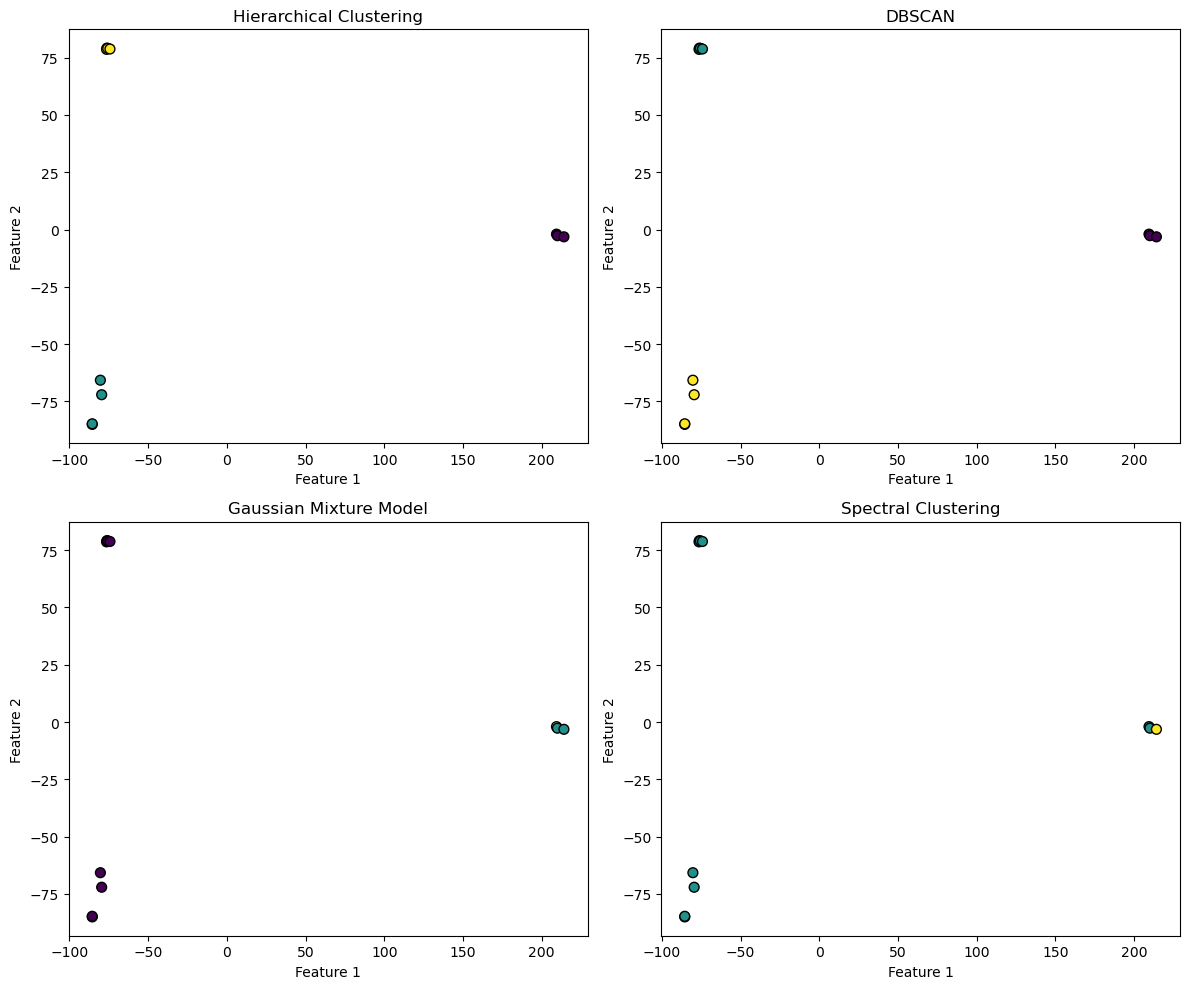

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
# Tạo dữ liệu giả lập (mảng vector)
X=np.array(list_vec)
#X, _ = make_blobs(n_samples=30, centers=4, cluster_std=0.6, random_state=42)
print(X)
# Định nghĩa số cụm
n_clusters = 3


# 1. Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
labels_hierarchical = hierarchical.fit_predict(X)
print(labels_hierarchical)
# 2. DBSCAN
dbscan = DBSCAN(eps=150, min_samples=2)
labels_dbscan = dbscan.fit_predict(X)
print(labels_dbscan)
# 3. Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
labels_gmm = gmm.fit_predict(X)
print(labels_gmm)
# 4. Spectral Clustering
spectral = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
labels_spectral = spectral.fit_predict(X)
print(labels_spectral)
# Hàm vẽ biểu đồ
def plot_clusters(X, labels, title):
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, edgecolor='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
#tsne = TSNE(n_components=2, random_state=42, perplexity=30)
#X_tsne = tsne.fit_transform(X)
# Vẽ kết quả phân cụm
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plot_clusters(X_pca, labels_hierarchical, 'Hierarchical Clustering')

plt.subplot(2, 2, 2)
plot_clusters(X_pca, labels_dbscan, 'DBSCAN')

plt.subplot(2, 2, 3)
plot_clusters(X_pca, labels_gmm, 'Gaussian Mixture Model')

plt.subplot(2, 2, 4)
plot_clusters(X_pca, labels_spectral, 'Spectral Clustering')

plt.tight_layout()
plt.show()
